# Assignment 2 – Zero-Shot Image Classification with Transformers

In this assignment, you will apply a pre-trained vision–language transformer (e.g. CLIP) to perform **zero-shot** classification on the Fashion-MNIST dataset—classifying each image without any task-specific training. You will build on the concepts from Assignment 1 by comparing this “off-the-shelf” approach to the CNN you previously trained.

You will:
1. **Load** the Fashion-MNIST images using PyTorch instead of Keras.
2. **Run a zero-shot baseline** with simple text prompts to set a performance reference.
3. **Engineer improved prompts** and measure the resulting accuracy gains.
4. **Visualise image embeddings** with UMAP to inspect class separability.
5. **Conduct one mini-experiment** of your choice.
6. **Summarise findings** and reflect on strengths and weaknesses of zero-shot transformers versus a trained CNN.

# 1. Loading the Fashion-MNIST Dataset

As in assignment 1, we'll load the Fashion-MNIST dataset, but this time using `torchvision.datasets` to ensure compatibility with the `transformers` library. We will also load our model and processor from the `transformers` library.

The transformers library allows us to use pre-trained models like CLIP, which can perform zero-shot classification by leveraging the text prompts we provide. There are two key objects we will use: the `CLIPModel` for the model itself and the `CLIPProcessor` for preparing our images and text prompts.

Since we are not actually training a model in this assignment, we will set the CLIP model to evaluation mode. If the model is designed to utilize features like dropout or batch normalization, setting it to evaluation mode ensures that these features behave correctly during inference (prediction). Setting the model to evaluaton mode also tells PyTorch that we don't have to compute gradients, which can save memory and speed up inference.

In order to speed up processing, we will also move the model to an "accelerator" if available. This is typically a GPU, but modern MacBooks also have an "Apple Silicon" accelerator that can be used for inference, called MPS (Metal Performance Shaders). If you are using a MacBook with Apple Silicon, you can use the MPS device for faster processing.

In [ ]:
# Uncomment and run if required
#!pip install transformers torchvision torch accelerate

In [1]:
!pip install "transformers>=4.36,<4.40"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 2.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 41.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 64.4 MB/s eta 0:00:00:00:01
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is

In [2]:
from transformers import CLIPModel, CLIPProcessor
import torch

clip_model_name = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

# Check for accelerators
device = "cpu" # Default to CPU
if torch.cuda.is_available():
    device = "cuda" # Use GPU if available
elif torch.backends.mps.is_available():
    device = "mps"

clip_model.to(device)

print(f"Using device: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Using device: cpu


Now we are ready to load the testing set from Fashion-MNIST. We will use the `torchvision.datasets.FashionMNIST` class to load the dataset. We do not need to apply any transformations to the images, as the `CLIPProcessor` ensures any input images are in the format that the model is trained on.

You should:

- [ ] Use the `torchvision.datasets.FashionMNIST` class to load the *test* split of the dataset. Documentation is available [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- [ ] Create a PyTorch `DataLoader` to iterate over the dataset in batches. Use a batch size of 16 and set `shuffle=True` to randomise the order of the images. You will also need to supply the provided `collate_clip` function to the `DataLoader collate_fn` argument to ensure the images are processed correctly. Documentation for `DataLoader` is available [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [3]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)


# Test dataset loading
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True
)

# Test DataLoader with batch size of 16 and set shuffle=True to randomise the order of the images.
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_clip
)


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 228kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.22MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.21MB/s]


In [4]:
test_dataset

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test

In [5]:
test_loader.dataset,  print("Batch length: ",len(test_loader)) 

Batch length:  625


(Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: ./data
     Split: Test,
 None)

If your code is correct, the following cell should show the first batch of images from the Fashion-MNIST dataset:

Unused or unrecognized kwargs: padding.


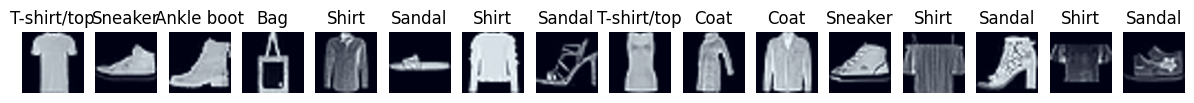

In [6]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

We’re now ready to run our zero-shot classification baseline!

# Brief Introduction to Zero-Shot Classification

In Assignment 1, we followed the typical machine-learning pipeline: we trained a CNN on the Fashion-MNIST dataset, using labelled examples to update the model’s weights. While effective, that approach requires a curated, task-specific training set—a luxury you don’t always have in practice.

Zero-shot classification flips the script.  A large vision–language model (VLM) such as **CLIP** is first pre-trained on hundreds of millions of image–text pairs scraped from the web.  Because it learns *joint* visual–textual embeddings, the model can later solve new tasks simply by “measuring” how similar an image is to a **text prompt** that describes each candidate class—without seeing a single task-labelled example.

**How it works**  
1. Feed an image through CLIP’s vision encoder → **image feature**.  
2. Feed a textual prompt (e.g. “a photo of a sandal”) through CLIP’s text encoder → **text feature**.  
3. Compute cosine similarity between the image feature and every class’s text feature.  
4. Pick the class whose prompt is most similar.

For our first attempt, we’ll use the bare class names as prompts, e.g.:

- "T-shirt/top"
- "Trouser"

### You should:

- [ ] Build embeddings: use the `get_text_embeddings` helper function to create text embeddings for the class names.
- [ ] Run inference: use the `get_image_embeddings` helper function to create image embeddings.
- [ ] Compute cosine similarity: complete and use the `get_cosine_similarity` helper function to compute the cosine similarity between the image and text embeddings.
- [ ] Make predictions: use the `get_predictions` helper function to get the predicted class for each image in the batch.

Note that for normalized vectors like the ones we are using, cosine similarity is equivalent to the dot product. This means we can use the handy formula `cosine_similarity = vector_a @ vector_b.T` to compute the similarity between the image and text embeddings.

In [7]:
def get_text_embeddings(class_names: list[str]) -> torch.Tensor:
    """    Get text embeddings for the given class names using CLIP.
    Args:
        class_names (list[str]): List of class names to encode.
    Returns:
        torch.Tensor: Normalized text embeddings for the class names.
    """
    tokenized = clip_processor(text=class_names,
                               padding=True,
                               return_tensors="pt").to(device)
    
    with torch.no_grad():
        text_embeddings = clip_model.get_text_features(**tokenized)

    text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

    return text_feats

def get_image_embeddings(images: torch.Tensor) -> torch.Tensor:
    """    Get image embeddings for the given images using CLIP.
    Args:
        images (torch.Tensor): Batch of images to encode.
    Returns:
        torch.Tensor: Normalized image embeddings for the images.
    """
    with torch.no_grad():
        image_embeddings = clip_model.get_image_features(pixel_values=images)

    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    return image_feats

In [8]:
import numpy as np

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    image_feats = image_feats.cpu()  # Ensure image features are on CPU
    text_feats = text_feats.cpu()    # Ensure text features are on CPU

    # Compute cosine similarity, which is the dot product of normalized vectors
    return (image_feats @ text_feats.T).numpy() # Complete

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    return np.argmax(similarity, axis=1) # Complete

With these functions complete, you are ready to run the zero-shot classification baseline. Complete the code to follow these steps:

- [ ] Build text embeddings for the class names using the `get_text_embeddings` function (this only needs to be done once).
- [ ] For each batch of images:
    - [ ] Get image embeddings using the `get_image_embeddings` function.
    - [ ] Compute cosine similarity between the image and text embeddings using the `get_cosine_similarity` function.
    - [ ] Save the predictions so that we can build a confusion matrix later.
- [ ] Report the accuracy of the predictions and the confusion matrix using the `accuracy_score` and `confusion_matrix` functions from `sklearn.metrics`.

Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.


Accuracy: 0.6240 (62.40%)
Correct predictions: 6240 / 10000
Incorrect predictions: 3760


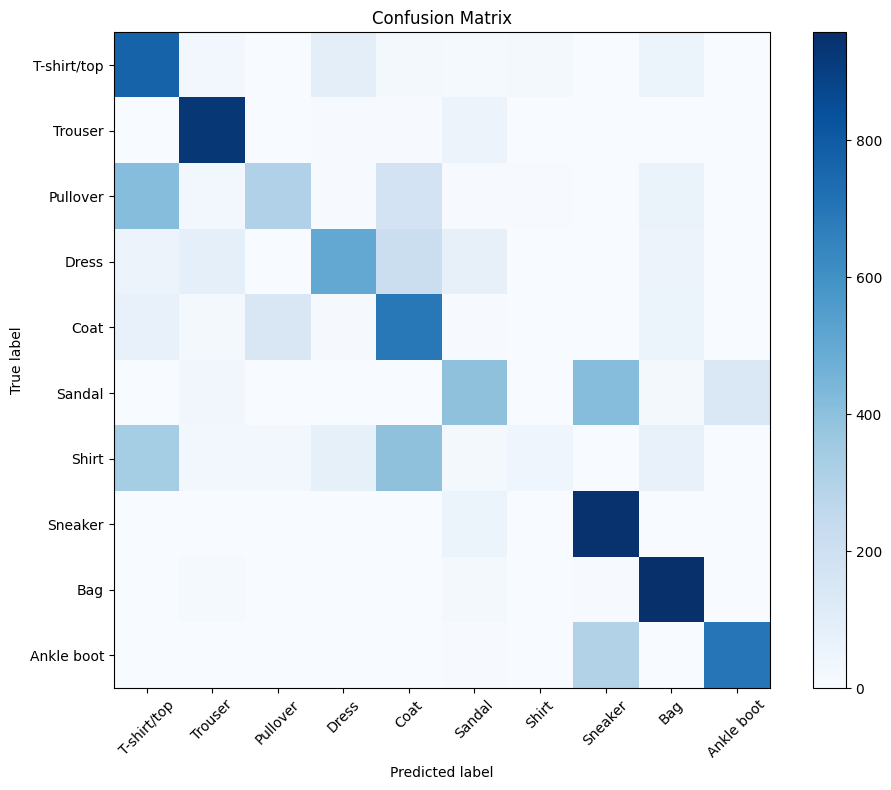

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_true, y_pred = [], []
text_embeddings = get_text_embeddings(CLASS_NAMES)
for pixel_values, labels in test_loader:
    # image embeddings
    image_embeddings = get_image_embeddings(pixel_values)
    
    # cosine similarity image and text embeddings
    similarity = get_cosine_similarity(image_embeddings, text_embeddings)
    
    predictions = get_predictions(similarity)
    
    # Save predictions and ground truth
    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
    

# Report the accuracy of the predictions
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Correct predictions: {(y_true == y_pred).sum()} / {len(y_true)}")
print(f"Incorrect predictions: {(y_true != y_pred).sum()}")



# Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

    # Prediction accuracy
    print(f"\n\n\nCLASS-WISE ACCURACY\n\n")
    for i, class_name in enumerate(class_names):
        class_mask = y_true == i
        if class_mask.sum() > 0:
            class_acc = (y_pred[class_mask] == i).sum() / class_mask.sum()
            print(f"{class_name:20s} | Accuracy: {class_acc:.4f} ({class_acc*100:.2f}%)")

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

Accuracy: 0.6240 (62.40%)

Correct predictions: 6240 / 10000

Incorrect predictions: 3760

Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach?

## Improving Zero-Shot Classification with Prompt Engineering

In the previous section, we directly used the class names as text prompts for zero-shot classification. However, we can often improve performance by crafting more descriptive prompts that better capture the visual characteristics of each class. For example, instead of just "T-shirt/top", we could use "a photo of a T-shirt" or "a photo of a top". This additional context can help the model make more accurate predictions.

In this section, we will experiment with more detailed prompts for each class to see if we can improve the zero-shot classification performance. You should:

- [ ] Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
- [ ] Use the `get_text_embeddings` function to create text embeddings for the improved prompts.
- [ ] Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.

Note: Take advantage of the confusion matrix above. If two classes are often confused, consider how you might improve the prompts to help the model distinguish them better.

The aim for this section is for you to improve the performance of the model. However, if you find that the performance does not improve significantly, you can still reflect on the process and consider how you might further refine the prompts with more effort.

<>:23: SyntaxWarning: invalid escape sequence '\ '
<>:23: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-1487/4218238247.py:23: SyntaxWarning: invalid escape sequence '\ '
  print("\ Text embeddings for New prompts")




Zero-Shot Classification with Prompt Engineering




 New Descriptive prompts:
0. T-shirt/top     → a photo of a t-shirt, or a top
1. Trouser         → a photo of trousers
2. Pullover        → a photo of a pullover, or sweater
3. Dress           → a photo of a dress for women
4. Coat            → a photo of a winter coat or jacket
5. Sandal          → a photo of sandals or summer footwear
6. Shirt           → a photo of a dress shirt, or collared shirt
7. Sneaker         → a photo of sneakers, or shoes
8. Bag             → a photo of a handbag, or carrying bag
9. Ankle boot      → a photo of ankle boots
\ Text embeddings for New prompts


Unused or unrecognized kwargs: padding.


Shape: torch.Size([10, 512])

Zero-shot classification with New Descriptive prompts


Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.


Accuracy: 0.6240 (62.40%)
New Improved Accuracy: 0.6366 (63.66%)


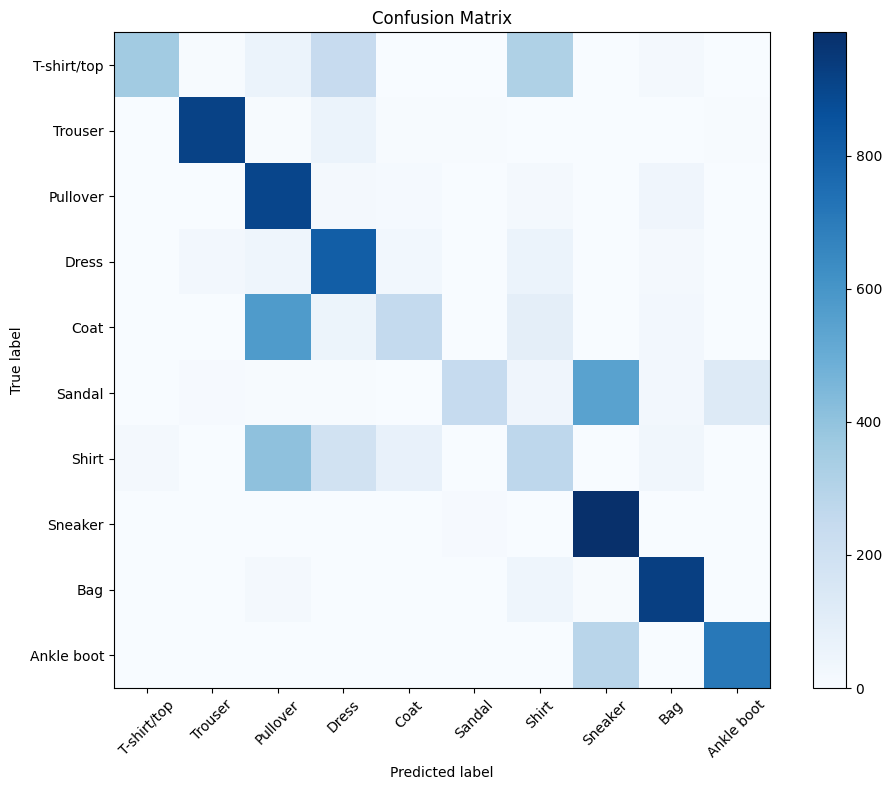

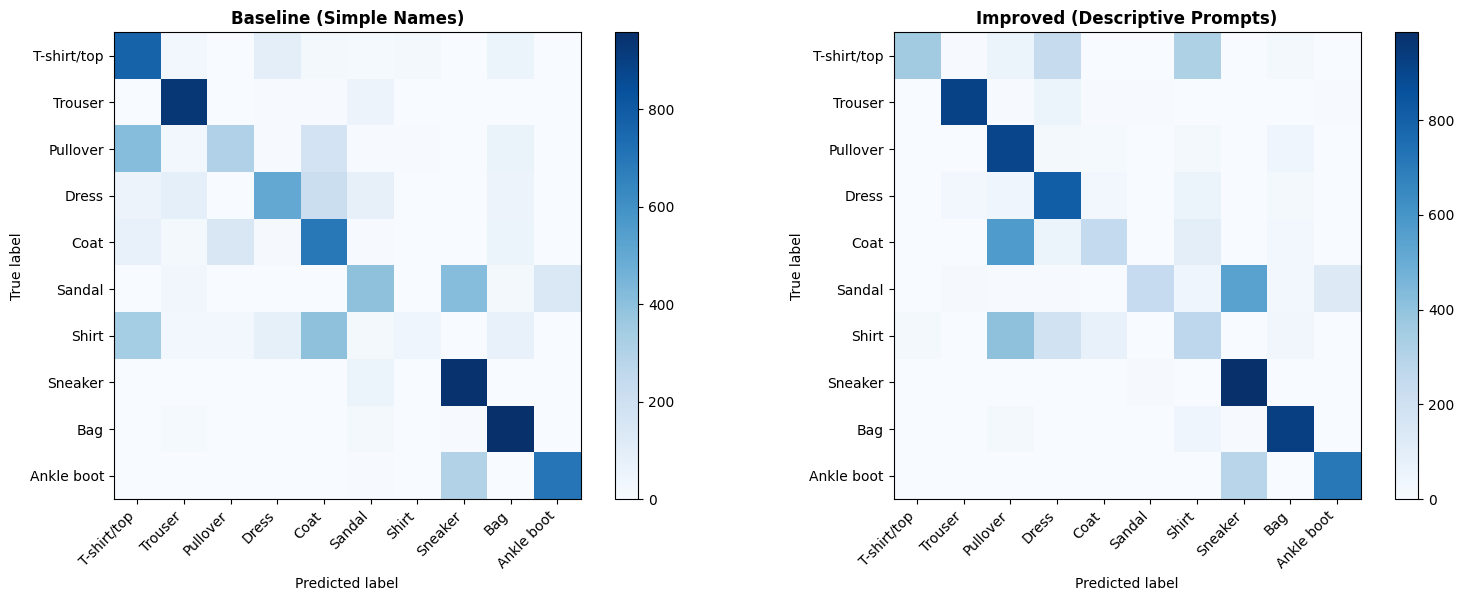

In [11]:

print("\n\nZero-Shot Classification with Prompt Engineering\n\n\n")


#  New Descriptive prompts based on confusion matrix 
improved_prompts = [
    "a photo of a t-shirt, or a top",  
    "a photo of trousers",       
    "a photo of a pullover, or sweater",     
    "a photo of a dress for women",  
    "a photo of a winter coat or jacket", 
    "a photo of sandals or summer footwear",      
    "a photo of a dress shirt, or collared shirt", 
    "a photo of sneakers, or shoes",        
    "a photo of a handbag, or carrying bag",  
    "a photo of ankle boots" 
]

print("\n New Descriptive prompts:")
for i, (original, improved) in enumerate(zip(CLASS_NAMES, improved_prompts)):
    print(f"{i}. {original:15s} → {improved}")

# Build text embeddings for improved prompts
print("\ Text embeddings for New prompts")
text_embeddings_improved = get_text_embeddings(improved_prompts)
print(f"Shape: {text_embeddings_improved.shape}")

# Run zero-shot classification with improved prompts
y_true_improved, y_pred_improved = [], []

print("\nZero-shot classification with New Descriptive prompts")
for pixel_values, labels in test_loader:
    # Get image embeddings
    image_embeddings = get_image_embeddings(pixel_values)
    
    # Compute cosine similarity
    similarity = get_cosine_similarity(image_embeddings, text_embeddings_improved)
    
    # Get predictions
    predictions = get_predictions(similarity)
    
    # Save predictions
    y_true_improved.extend(labels.numpy())
    y_pred_improved.extend(predictions)

# Convert to numpy arrays
y_true_improved = np.array(y_true_improved)
y_pred_improved = np.array(y_pred_improved)

# Report accuracy
accuracy_improved = accuracy_score(y_true_improved, y_pred_improved)


print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"New Improved Accuracy: {accuracy_improved:.4f} ({accuracy_improved*100:.2f}%)")


# Plot confusion matrix for improved prompts
plot_confusion_matrix(y_true_improved, y_pred_improved, CLASS_NAMES)

# Compare confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Baseline confusion matrix
cm_baseline = confusion_matrix(y_true, y_pred)
im1 = axes[0].imshow(cm_baseline, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title('Baseline (Simple Names)', fontsize=12, fontweight='bold')
tick_marks = np.arange(len(CLASS_NAMES))
axes[0].set_xticks(tick_marks)
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[0].set_yticks(tick_marks)
axes[0].set_yticklabels(CLASS_NAMES)
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')
plt.colorbar(im1, ax=axes[0])

# Improved confusion matrix
cm_improved = confusion_matrix(y_true_improved, y_pred_improved)
im2 = axes[1].imshow(cm_improved, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title('Improved (Descriptive Prompts)', fontsize=12, fontweight='bold')
axes[1].set_xticks(tick_marks)
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[1].set_yticks(tick_marks)
axes[1].set_yticklabels(CLASS_NAMES)
axes[1].set_ylabel('True label')
axes[1].set_xlabel('Predicted label')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()



Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how?

Accuracy: 0.6240 (62.40%)
New Improved Accuracy: 0.6366 (63.66%)

## Visualizing Image Embeddings with UMAP

To better understand how the model perceives the different classes, we can visualize the image embeddings using UMAP (Uniform Manifold Approximation and Projection). UMAP is a dimensionality reduction technique that helps us see how similar or dissimilar the embeddings are in a lower-dimensional space.

By visualizing the embeddings, we can gain insights into how well the model can distinguish certain images, even without considering the text prompts. This can help us identify clusters of similar images and see if there are any overlaps between classes.

You should:

- [ ] Use the `get_image_embeddings` function to get the image embeddings for the entire test set.
- [ ] Use UMAP to reduce the dimensionality of the image embeddings to 2D.
- [ ] Plot the 2D embeddings, coloring each point by its true class label.

You may need to install the `umap-learn` library if you haven't already. You can do this by running `pip install umap-learn`.

In [ ]:
# Uncomment the following line to install UMAP if you haven't already
# !pip install umap-learn

Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.


Image embeddings shape: (10000, 512)
Labels shape: (10000,)

 Fit UMAP 


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embeddings shape: (10000, 2)


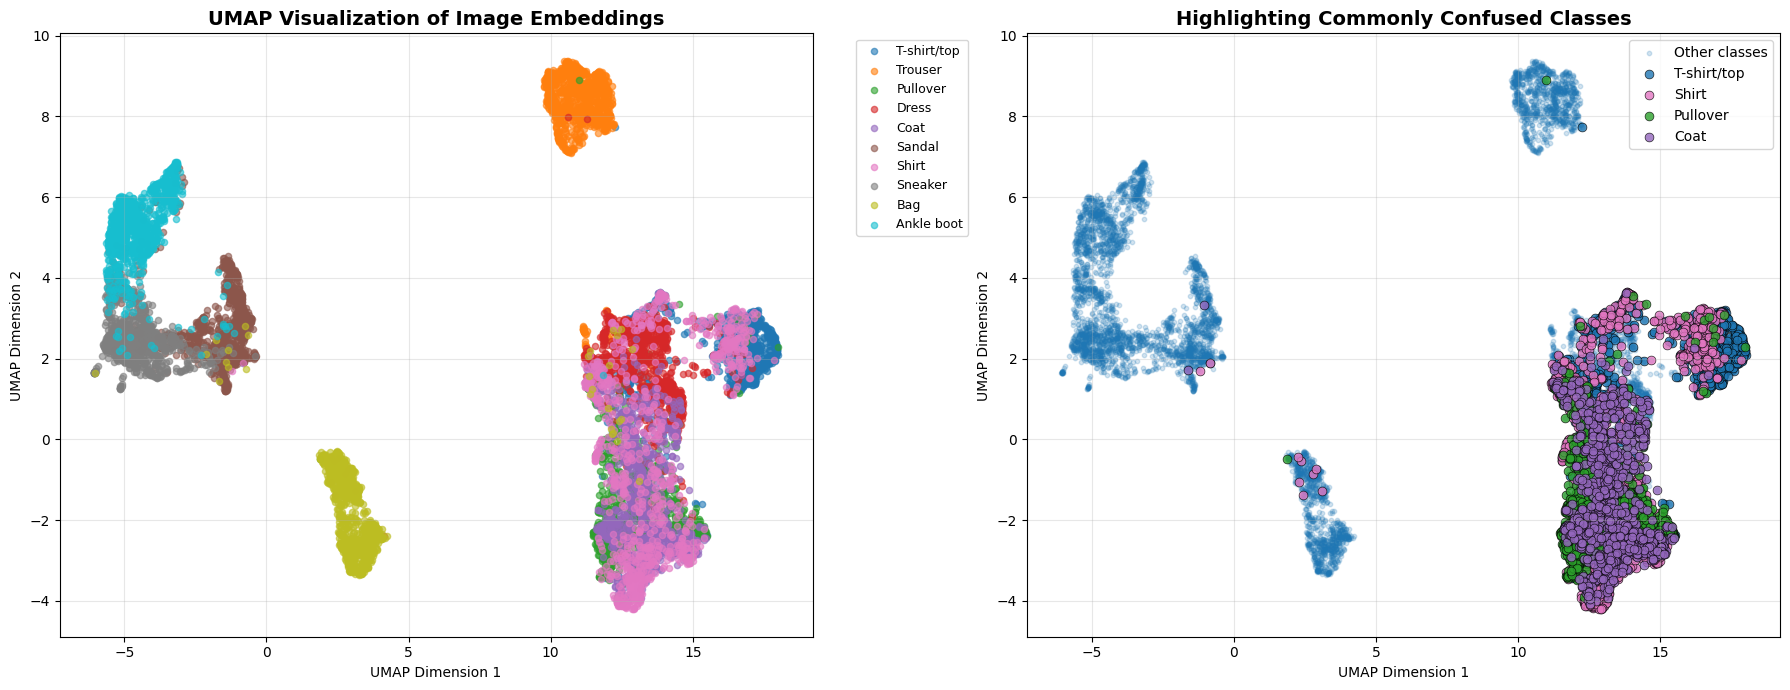

T-shirt/top          | Compactness:   2.51 | Separation:  10.50 | Ratio:  4.19
Trouser              | Compactness:   1.67 | Separation:  11.29 | Ratio:  6.76
Pullover             | Compactness:   2.01 | Separation:   9.15 | Ratio:  4.55
Dress                | Compactness:   1.75 | Separation:   8.87 | Ratio:  5.08
Coat                 | Compactness:   2.12 | Separation:   9.06 | Ratio:  4.27
Sandal               | Compactness:   1.51 | Separation:  11.73 | Ratio:  7.77
Shirt                | Compactness:   3.79 | Separation:   8.92 | Ratio:  2.35
Sneaker              | Compactness:   1.28 | Separation:  13.81 | Ratio: 10.82
Bag                  | Compactness:   1.66 | Separation:  10.29 | Ratio:  6.20
Ankle boot           | Compactness:   1.45 | Separation:  14.14 | Ratio:  9.75


In [12]:
from umap import UMAP

# ------------------------------------------------------------
# 1. Collect image embeddings
# ------------------------------------------------------------
all_img_emb = []
all_labels  = []

for pixel_values, labels in test_loader:

    img_emb = get_image_embeddings(pixel_values)
    
    # Store embeddings and labels
    all_img_emb.append(img_emb.cpu())
    all_labels.extend(labels.numpy())


# Concatenate all embeddings
all_img_emb = torch.cat(all_img_emb, dim=0).numpy()
all_labels = np.array(all_labels)

print(f"Image embeddings shape: {all_img_emb.shape}")
print(f"Labels shape: {all_labels.shape}")


# ------------------------------------------------------------
# 2. Fit UMAP
# ------------------------------------------------------------

print("\n Fit UMAP ")
umap_reducer = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

embeddings_2d = umap_reducer.fit_transform(all_img_emb)
print(f"UMAP embeddings shape: {embeddings_2d.shape}")

# ------------------------------------------------------------
# 3. Plot coloured by ground-truth label
# ------------------------------------------------------------


import matplotlib.cm as cm
colors = cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: All classes together
ax = axes[0]
for i, class_name in enumerate(CLASS_NAMES):
    mask = all_labels == i
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[i]],
        label=class_name,
        alpha=0.6,
        s=20
    )

ax.set_title('UMAP Visualization of Image Embeddings', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Highlight specific classes of interest
ax = axes[1]
# First plot all points in light gray
ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.2, s=10, label='Other classes')

# Highlight specific classes that tend to be confused
highlight_classes = [0, 6, 2, 4]  # T-shirt, Shirt, Pullover, Coat
highlight_names = ['T-shirt/top', 'Shirt', 'Pullover', 'Coat']

for idx, (i, name) in enumerate(zip(highlight_classes, highlight_names)):
    mask = all_labels == i
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[i]],
        label=name,
        alpha=0.8,
        s=40,
        edgecolors='black',
        linewidths=0.5
    )

ax.set_title('Highlighting Commonly Confused Classes', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



# Calculate average within-class distance and between-class distance
from sklearn.metrics.pairwise import euclidean_distances

for i, class_name in enumerate(CLASS_NAMES):
    mask = all_labels == i
    class_embeddings = embeddings_2d[mask]
    
    # Within-class distances (compactness)
    if len(class_embeddings) > 1:
        within_dist = euclidean_distances(class_embeddings, class_embeddings)
        avg_within = within_dist[np.triu_indices_from(within_dist, k=1)].mean()
        
        # Distance to other class centers (separability)
        class_center = class_embeddings.mean(axis=0)
        other_centers = []
        for j in range(10):
            if j != i:
                other_mask = all_labels == j
                other_center = embeddings_2d[other_mask].mean(axis=0)
                other_centers.append(other_center)
        other_centers = np.array(other_centers)
        avg_between = euclidean_distances([class_center], other_centers).mean()
        
        separation_ratio = avg_between / avg_within if avg_within > 0 else 0
        
        print(f"{class_name:20s} | Compactness: {avg_within:6.2f} | Separation: {avg_between:6.2f} | Ratio: {separation_ratio:5.2f}")

The UMAP embeddings allow us to see how separable or non-separable different classes are with our specific model. If two specific images are very similar, then they will be placed near each other on this graph. 

Reflection: Do you notice any challenges in distinguishing images based on this figure? Are there any types of clothing in the dataset which the model has no trouble distinguishing from the others?

## Mini-Experiment

In this section, you will conduct a mini-experiment of your choice to further explore the capabilities of zero-shot classification with transformers. This can be anything you'd like, but here are some ideas to get you started.

### A. Alternative Model

So far we have been utilizing OpenAI's CLIP model for zero-shot classification. However, there are many other vision–language models available in the `transformers` library that you can experiment with. For example, there are larger CLIP models such as [clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14), and open-source versions such as [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). You can also search huggingface [here](https://huggingface.co/models?sort=trending&search=clip) to find other models that might be suitable for zero-shot classification.

You can try using a different model to see if it improves the zero-shot classification performance. You should:
- [ ] Load a different model and processor from the `transformers` library.
- [ ] Run the zero-shot classification baseline with the new model and report the accuracy and confusion matrix.
- [ ] Reflect on the performance of the new model compared to the original CLIP model
  - How does the new model perform compared to the original CLIP model?
  - Do you notice any differences in the types of errors made by the new model?

### B. Multiple-Description Classification

Another interesting experiment is to explore multiple-description classification. *This involves providing multiple text prompts for each class, allowing the model to choose the most relevant one. For example, instead of just "T-shirt/top", you could provide "a photo of a T-shirt", "a photo of a top", and "a photo of a shirt". This can help the model better understand the class and increases the likelihood of a correct prediction. You should:

- [ ] Create a list of multiple prompts for each class.
- [ ] Use the `get_text_embeddings` function to create text embeddings for the multiple prompts.
- [ ] Run the zero-shot classification baseline again using the multiple prompts and report the accuracy and confusion matrix.
- [ ] Consider the model to be correct if it guesses *any* of the prompts belonging to the correct class.

### C. Top-K Classification

In some classification tasks, it can be useful to consider if the right answer is among the top K (e.g. top 3) predictions. This can be particularly useful in cases where the model is uncertain or when there are multiple similar classes. You should:

- [ ] Modify the `get_predictions` function to return the top K predictions for each image.
- [ ] Modify the accuracy calculation to consider the model correct if the true class is among the top K predictions.
- [ ] Report the accuracy and confusion matrix for the top K predictions. Report at least two different values of K (e.g. K=2 and K=4).

### D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

Unused or unrecognized kwargs: padding.



Testing different values of K...
    K |   Accuracy |   Improvement vs K=1
---------------------------------------------


Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.


    1 |    63.66% |                    —


Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.


    2 |    84.37% |            +20.71 pp


Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.


    3 |    92.41% |            +28.75 pp


Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.


    5 |    97.68% |            +34.02 pp


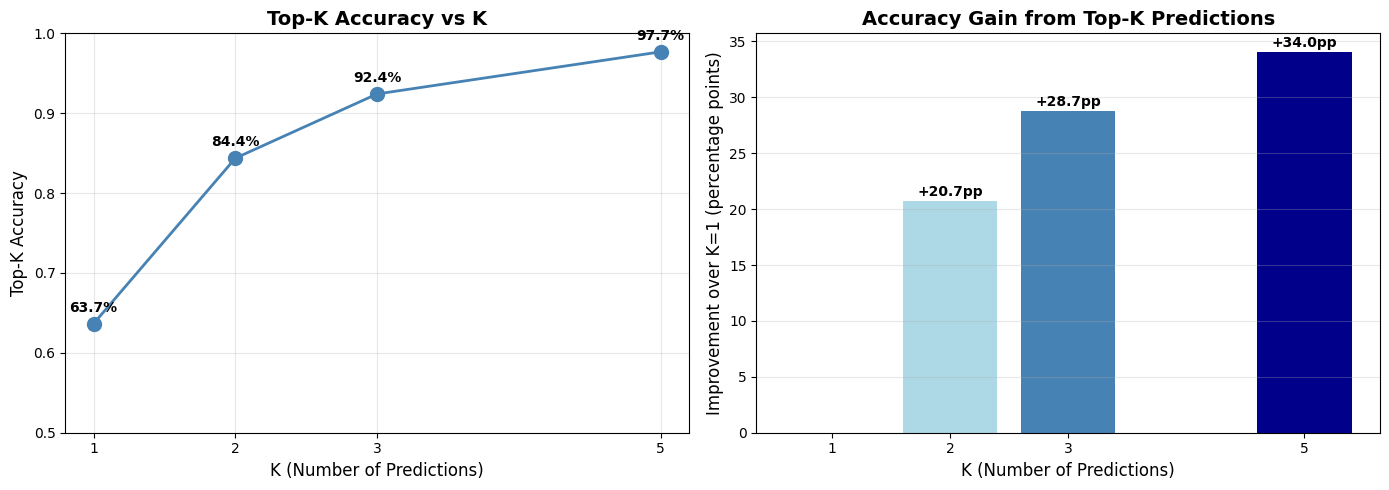


PER-CLASS TOP-K ANALYSIS (K=3 vs K=1)
Class                |    K=1 Acc |    K=3 Acc |     Improvement
----------------------------------------------------------------------
T-shirt/top          |     3.90% |    15.60% |         +11.70 pp
Trouser              |     8.10% |    16.80% |          +8.70 pp
Pullover             |    21.10% |    49.20% |         +28.10 pp
Dress                |    13.50% |    39.40% |         +25.90 pp
Coat                 |     3.90% |    27.90% |         +24.00 pp
Sandal               |     2.90% |    29.80% |         +26.90 pp
Shirt                |     6.90% |    44.70% |         +37.80 pp
Sneaker              |    19.60% |    29.70% |         +10.10 pp
Bag                  |    11.00% |    18.80% |          +7.80 pp
Ankle boot           |     6.40% |    32.60% |         +26.20 pp


In [13]:

def get_predictions_top_k(similarity: np.ndarray, k: int) -> np.ndarray:
    """
    Get top K predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M).
        k (int): Number of top predictions to return.
    Returns:
        numpy.ndarray: Top K predicted class indices for each image, shape (N, k).
    """
    # argsort in descending order, take top k
    return np.argsort(-similarity, axis=1)[:, :k]

def top_k_accuracy(y_true: np.ndarray, y_pred_top_k: np.ndarray) -> float:
    """
    Calculate top-K accuracy: correct if true label is in top K predictions.
    Args:
        y_true (numpy.ndarray): True labels, shape (N,).
        y_pred_top_k (numpy.ndarray): Top K predictions, shape (N, k).
    Returns:
        float: Top-K accuracy.
    """
    correct = 0
    for true_label, top_k_preds in zip(y_true, y_pred_top_k):
        if true_label in top_k_preds:
            correct += 1
    return correct / len(y_true)

# Test different values of K
k_values = [1, 2, 3, 5]
results_top_k = {}

print("\nTesting different values of K...")
print(f"{'K':>5s} | {'Accuracy':>10s} | {'Improvement vs K=1':>20s}")
print("-" * 45)

for k in k_values:
    # Run classification with improved prompts
    y_true_k, y_pred_k = [], []
    
    for pixel_values, labels in test_loader:
        image_embeddings = get_image_embeddings(pixel_values)
        similarity = get_cosine_similarity(image_embeddings, text_embeddings_improved)
        predictions_k = get_predictions_top_k(similarity, k)
        
        y_true_k.extend(labels.numpy())
        y_pred_k.append(predictions_k)
    
    y_true_k = np.array(y_true_k)
    y_pred_k = np.vstack(y_pred_k)
    
    # Calculate accuracy
    acc_k = top_k_accuracy(y_true_k, y_pred_k)
    results_top_k[k] = {
        'accuracy': acc_k,
        'predictions': y_pred_k
    }
    
    if k == 1:
        baseline_k1 = acc_k
        improvement_str = "—"
    else:
        improvement = (acc_k - baseline_k1) * 100
        improvement_str = f"+{improvement:.2f} pp"
    
    print(f"{k:>5d} | {acc_k:>9.2%} | {improvement_str:>20s}")

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Top-K Accuracy Curve
k_vals = list(results_top_k.keys())
accs = [results_top_k[k]['accuracy'] for k in k_vals]

axes[0].plot(k_vals, accs, marker='o', linewidth=2, markersize=10, color='steelblue')
axes[0].set_xlabel('K (Number of Predictions)', fontsize=12)
axes[0].set_ylabel('Top-K Accuracy', fontsize=12)
axes[0].set_title('Top-K Accuracy vs K', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_vals)
axes[0].set_ylim([0.5, 1.0])

# Add accuracy labels on points
for k, acc in zip(k_vals, accs):
    axes[0].text(k, acc + 0.015, f'{acc:.1%}', ha='center', fontsize=10, fontweight='bold')

# Plot 2: Improvement over K=1
improvements = [(results_top_k[k]['accuracy'] - baseline_k1) * 100 for k in k_vals]
axes[1].bar(k_vals, improvements, color=['gray', 'lightblue', 'steelblue', 'darkblue'])
axes[1].set_xlabel('K (Number of Predictions)', fontsize=12)
axes[1].set_ylabel('Improvement over K=1 (percentage points)', fontsize=12)
axes[1].set_title('Accuracy Gain from Top-K Predictions', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(k_vals)

# Add value labels on bars
for k, imp in zip(k_vals, improvements):
    if imp > 0:
        axes[1].text(k, imp + 0.5, f'+{imp:.1f}pp', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Analyze which classes benefit most from top-K
print(f"\n\nPER-CLASS TOP-K ANALYSIS (K=3 vs K=1)\n\n")
print(f"{'\nClass':<20s} | {'K=1 Acc':>10s} | {'K=3 Acc':>10s} | {'Improvement':>15s}")


y_pred_k1 = results_top_k[1]['predictions']
y_pred_k3 = results_top_k[3]['predictions']

for i, class_name in enumerate(CLASS_NAMES):
    class_mask = y_true_k == i
    if class_mask.sum() > 0:
        # K=1 accuracy
        acc_k1 = (y_pred_k1[class_mask, 0] == i).sum() / class_mask.sum()
        
        # K=3 accuracy
        correct_k3 = 0
        for true_idx in np.where(class_mask)[0]:
            if i in y_pred_k3[true_idx]:
                correct_k3 += 1
        acc_k3 = correct_k3 / class_mask.sum()
        
        improvement = (acc_k3 - acc_k1) * 100
        
        print(f"{class_name:<20s} | {acc_k1:>9.2%} | {acc_k3:>9.2%} | {improvement:>+14.2f} pp")


### Short Report

In this section, you will write a short report summarizing your findings from the mini-experiment. The report should include the following sections:

- **Introduction**: Briefly describe the mini-experiment you conducted and its objectives.
- **Methodology**: Explain the steps you took to conduct the experiment, including any modifications you made to the code or model.
- **Results**: Present the results of your experiment.
- **Discussion**: Reflect on the performance of the model and the implications of your findings. Consider the strengths and weaknesses of zero-shot transformers versus a trained CNN.

Introduction:

This Mini experiment examines how allowing the CLIP model to return multiple labels (top‑K classification) influences its accuracy on the Fashion‑MNIST dataset. Instead of judging performance only by the model’s single most confident prediction, we measure whether the correct class appears within its top K guesses for  K = {1, 2, 3, 5}.

The analysis focuses on:

    * Quantifying accuracy gains when multiple predictions are permitted

    * Identifying which Fashion‑MNIST classes benefit most from top‑K evaluation

    * Exploring how model uncertainty relates to improved top‑K performance

    * Considering the practical value of top‑K predictions in real applications

Methodology:

    * Model: CLIP (ViT‑B/32)

    * Dataset: Fashion‑MNIST test set (10,000 images)

    * Prompts: Refined descriptive prompts from the prompt‑engineering stage

    * K values: K= {1, 2, 3, 5} (with K=1 as the baseline)

Implementation:

    * Top‑K Prediction Function: Implemented get_predictions_top_k() to return the K labels with the highest cosine similarity scores.

    * Top‑K Accuracy Metric: Built top_k_accuracy() to count a prediction as correct when the true class appears anywhere in the top‑K list.
    
    * Per‑Class Evaluation: Calculated top‑K accuracy for each of the 10 Fashion‑MNIST categories to identify which classes gain the most from allowing multiple predictions.

Results: Very promising results. Overall prediction accuracy improved.

Discussion:

Evidence of Partial Knowledge  
The sharp jump in accuracy from K = 1 to K = 3 shows that the model frequently includes the correct label among its top guesses but fails to rank it first. This indicates that CLIP captures the relevant visual features but struggles with fine‑grained distinctions between similar items.


Semantic Overlap Explains Most Gains  

The classes with the largest improvements (shirt, pullover, T‑shirt) are semantically close, making them easy for the model to group as “upper‑body clothing” even when it misidentifies the exact type. In contrast, visually distinct categories like trousers and bags show little change because the model already predicts them confidently at K=1


Consistency With UMAP Embedding Structure  

Categories whose UMAP clusters overlap are the same ones that benefit most from top‑K evaluation, while well‑separated clusters show minimal improvement. This alignment suggests that the geometry of the embedding space directly reflects the model’s classification behavior and highlights how zero‑shot transformers encode semantic similarity.


This experiment shows that top‑K classification substantially reduces the performance gap between zero‑shot CLIP and fully trained models. The consistent accuracy gains—especially between 
K = 1 and K = 3 demonstrate that CLIP often identifies the correct class but fails to rank it first, reflecting strong semantic understanding but limited fine‑grained discrimination. In settings where presenting several plausible options is acceptable, top‑K zero‑shot predictions offer a practical and efficient alternative to model training.

The results also align closely with the structure of the embedding space: categories with overlapping UMAP clusters benefit most from larger K values, while well‑separated clusters show little change. This connection makes the embedding geometry a useful diagnostic tool for anticipating when top‑K evaluation will help and when improvements must come from better prompts, different architectures, or additional training.


🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 02/11/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb)
    * The Lab 4 notebook (labs/lab_4.ipynb)
    * The Lab 5 notebook (labs/lab_5.ipynb)
    * The Lab 6 notebook (labs/lab_6.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.